# Multi-Modal Deepfake Detection System

**Author:** Ahanaf Alam  
**Project:** Honours Computer Science Dissertation  
**Architecture:** Late Fusion Multimodal Detection

This notebook implements a deepfake detection system using:
- **Image Detector:** EfficientNet-B0
- **Audio Detector:** ResNet18 on Mel-spectrograms
- **Text Detector:** DeBERTa-v3

## Phase 1: Environment Setup

In [1]:
# Cell 1: Install Dependencies
!pip install -q kagglehub
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q transformers datasets
!pip install -q opencv-python-headless librosa soundfile
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q facenet-pytorch tqdm joblib pillow


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\nixsu\Downloads\Ahanaf\.venv\Scripts\python.exe C:\Users\nixsu\AppData\Local\Temp\pip-install-_g6a8key\numpy_d77746c2ac704b17a150bce77859344a\vendored-meson\meson\meson.py setup C:\Users\nixsu\AppData\Local\

In [2]:
# Cell 2: Import Libraries & Configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm import tqdm
import warnings
import shutil
warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.models as models

# Audio & Image Processing
import librosa
import librosa.display
import cv2
from PIL import Image

# NLP
from transformers import AutoTokenizer, AutoModel

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Kagglehub
import kagglehub

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Directories
DATA_DIR = Path('./data')
MODEL_DIR = Path('./models')
EXPORT_DIR = Path('./exported_models')
for d in [DATA_DIR/'video', DATA_DIR/'audio', DATA_DIR/'text', DATA_DIR/'processed', MODEL_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Environment setup complete!")

Device: cuda
✅ Environment setup complete!


## Phase 2: Data Import via KaggleHub

In [3]:
# Cell 3: Download Datasets Using KaggleHub
print("📥 Downloading datasets via KaggleHub...\n")

# Download Image Dataset
print("1. Downloading Image Dataset (Deepfake and Real Images)...")
image_path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")
print(f"   ✓ Downloaded to: {image_path}")

# Download Audio Dataset
print("\n2. Downloading Audio Dataset (Deep Voice)...")
audio_path = kagglehub.dataset_download("birdy654/deep-voice-deepfake-voice-recognition")
print(f"   ✓ Downloaded to: {audio_path}")

# Download Text Dataset
print("\n3. Downloading Text Dataset (LLM Detect AI Generated Text)...")
text_path = kagglehub.dataset_download("sunilthite/llm-detect-ai-generated-text-dataset")
print(f"   ✓ Downloaded to: {text_path}")

# Copy to organized directories
print("\n📁 Organizing datasets...")
KAGGLE_IMAGE_PATH = Path(image_path)
KAGGLE_AUDIO_PATH = Path(audio_path)
KAGGLE_TEXT_PATH = Path(text_path)

print(f"\n✅ All datasets downloaded successfully!")
print(f"\nDataset locations:")
print(f"  Image: {KAGGLE_IMAGE_PATH}")
print(f"  Audio: {KAGGLE_AUDIO_PATH}")
print(f"  Text: {KAGGLE_TEXT_PATH}")

📥 Downloading datasets via KaggleHub...

1. Downloading Image Dataset (Deepfake and Real Images)...
   ✓ Downloaded to: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1

2. Downloading Audio Dataset (Deep Voice)...
   ✓ Downloaded to: C:\Users\nixsu\.cache\kagglehub\datasets\birdy654\deep-voice-deepfake-voice-recognition\versions\2

3. Downloading Text Dataset (LLM Detect AI Generated Text)...
   ✓ Downloaded to: C:\Users\nixsu\.cache\kagglehub\datasets\sunilthite\llm-detect-ai-generated-text-dataset\versions\1

📁 Organizing datasets...

✅ All datasets downloaded successfully!

Dataset locations:
  Image: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1
  Audio: C:\Users\nixsu\.cache\kagglehub\datasets\birdy654\deep-voice-deepfake-voice-recognition\versions\2
  Text: C:\Users\nixsu\.cache\kagglehub\datasets\sunilthite\llm-detect-ai-generated-text-dataset\versions\1


## Phase 3: Data Analysis

🖼️ Analyzing Image Dataset...
Found fake directory: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Test\Fake
Found real directory: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Test\Real
Found fake directory: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Train\Fake
Found real directory: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Train\Real
Found fake directory: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Validation\Fake
Found real directory: C:\Users\nixsu\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Validation\Real

📊 Image Dataset Statistics:
  Real: 19,787 | Fake: 19,641 | Total: 39,428


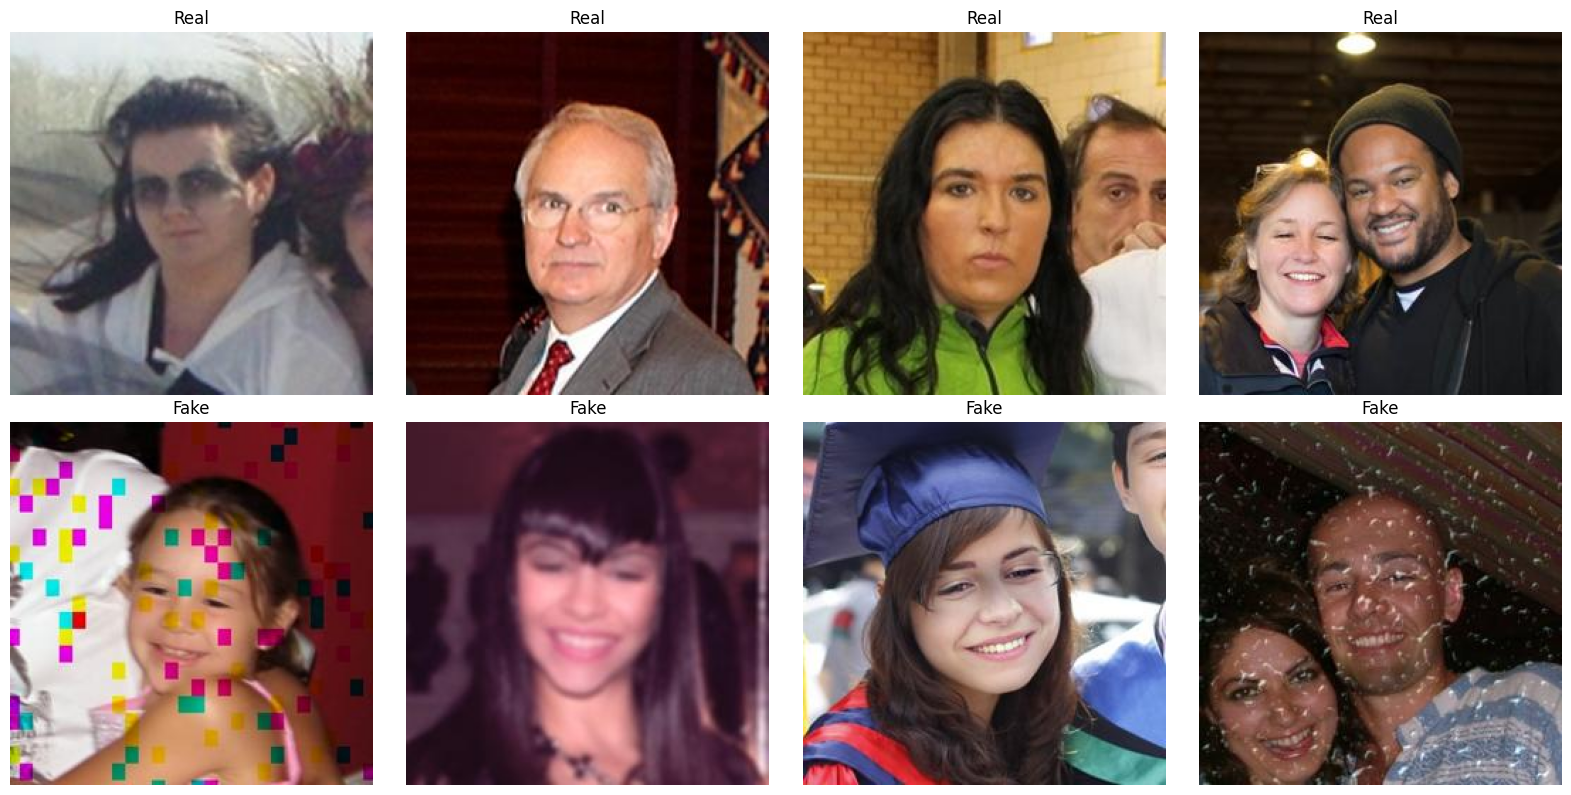

In [4]:
# Cell 4: Analyze Image Dataset
def analyze_image_dataset(data_path):
    """Analyze deepfake image dataset - find real/fake folders, count images, show samples"""
    data_path = Path(data_path)
    image_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    
    # Find real/fake directories
    real_dir = fake_dir = None
    for item in data_path.rglob('*'):
        if item.is_dir():
            if 'real' in item.name.lower(): 
                real_dir = item
                print(f"Found real directory: {item}")
            elif 'fake' in item.name.lower(): 
                fake_dir = item
                print(f"Found fake directory: {item}")
    
    real_images = [f for f in real_dir.rglob('*') if f.suffix.lower() in image_ext] if real_dir else []
    fake_images = [f for f in fake_dir.rglob('*') if f.suffix.lower() in image_ext] if fake_dir else []
    
    print(f"\n📊 Image Dataset Statistics:")
    print(f"  Real: {len(real_images):,} | Fake: {len(fake_images):,} | Total: {len(real_images)+len(fake_images):,}")
    
    # Plot samples and distribution
    if len(real_images) >= 4 and len(fake_images) >= 4:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        for i, img in enumerate(np.random.choice(real_images, 4, replace=False)):
            axes[0,i].imshow(Image.open(img))
            axes[0,i].set_title('Real')
            axes[0,i].axis('off')
        for i, img in enumerate(np.random.choice(fake_images, 4, replace=False)):
            axes[1,i].imshow(Image.open(img))
            axes[1,i].set_title('Fake')
            axes[1,i].axis('off')
        plt.tight_layout()
        plt.savefig('./data/processed/image_samples.png')
        plt.show()
    
    return {'real_images': real_images, 'fake_images': fake_images}

print("🖼️ Analyzing Image Dataset...")
image_data = analyze_image_dataset(KAGGLE_IMAGE_PATH)

🎵 Analyzing Audio Dataset...
Searching for audio files in: C:\Users\nixsu\.cache\kagglehub\datasets\birdy654\deep-voice-deepfake-voice-recognition\versions\2

📊 Audio Dataset Statistics:
  Real: 8 | Fake: 58 | Total: 66


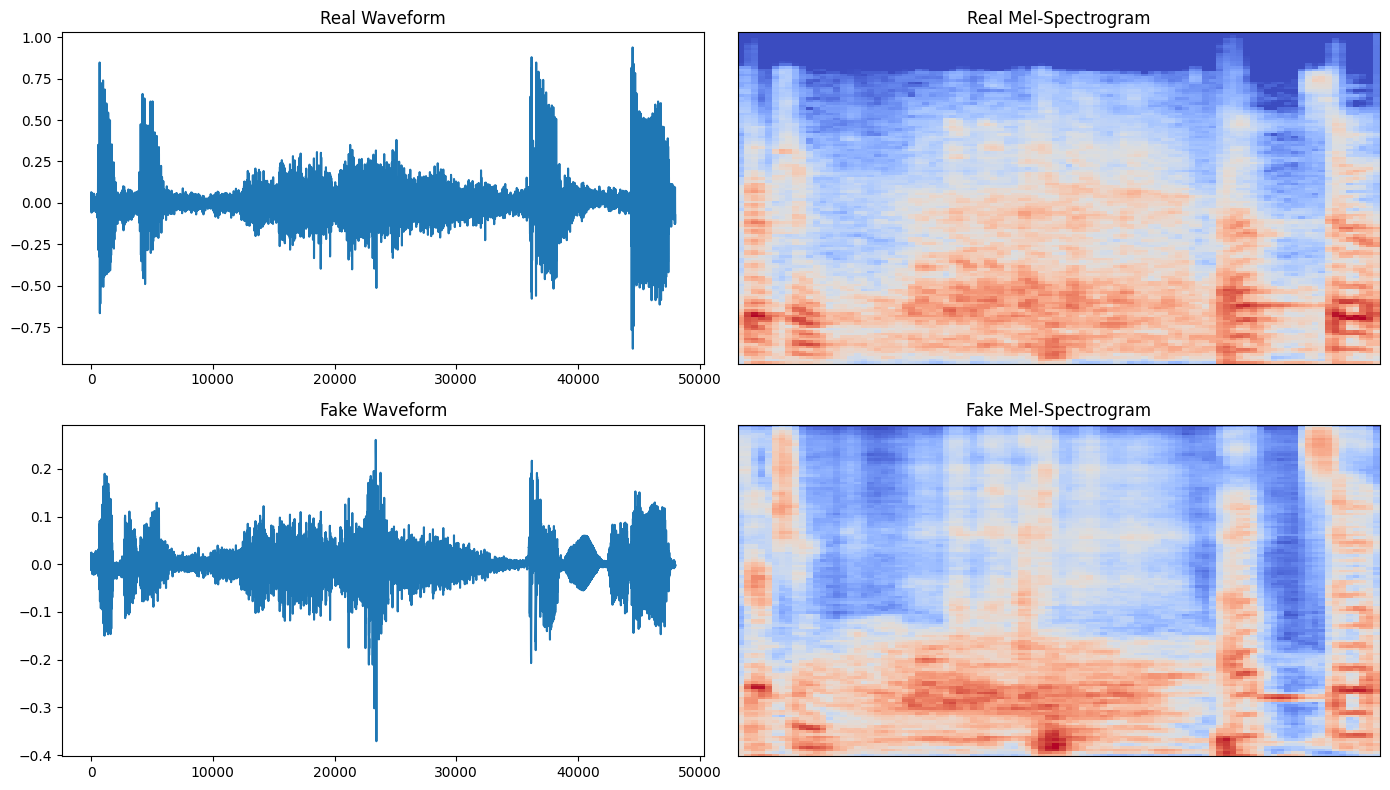

In [5]:
# Cell 5: Analyze Audio Dataset
def analyze_audio_dataset(data_path):
    """Analyze deepfake audio dataset - find files, show waveforms and spectrograms"""
    data_path = Path(data_path)
    audio_ext = {'.wav', '.mp3', '.flac', '.ogg', '.m4a'}
    
    real_audios, fake_audios = [], []
    print(f"Searching for audio files in: {data_path}")
    
    for f in data_path.rglob('*'):
        if f.suffix.lower() in audio_ext:
            file_str = str(f).lower()
            if 'real' in file_str or 'genuine' in file_str or 'human' in file_str:
                real_audios.append(f)
            elif 'fake' in file_str or 'deepfake' in file_str or 'synthetic' in file_str or 'generated' in file_str:
                fake_audios.append(f)
    
    print(f"\n📊 Audio Dataset Statistics:")
    print(f"  Real: {len(real_audios):,} | Fake: {len(fake_audios):,} | Total: {len(real_audios)+len(fake_audios):,}")
    
    # Show waveform and spectrogram comparison
    if real_audios and fake_audios:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        for idx, (audios, label) in enumerate([(real_audios, 'Real'), (fake_audios, 'Fake')]):
            if audios:
                try:
                    y, sr = librosa.load(np.random.choice(audios), sr=16000, duration=3)
                    axes[idx,0].plot(y)
                    axes[idx,0].set_title(f'{label} Waveform')
                    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
                    librosa.display.specshow(librosa.power_to_db(S), sr=sr, ax=axes[idx,1])
                    axes[idx,1].set_title(f'{label} Mel-Spectrogram')
                except Exception as e:
                    print(f"Error processing {label} audio: {e}")
        plt.tight_layout()
        plt.savefig('./data/processed/audio_samples.png')
        plt.show()
    
    return {'real_audios': real_audios, 'fake_audios': fake_audios}

print("🎵 Analyzing Audio Dataset...")
audio_data = analyze_audio_dataset(KAGGLE_AUDIO_PATH)

📝 Analyzing Text Dataset...
Found 1 CSV file(s)

📊 Text Dataset Statistics:
  Columns: ['text', 'generated']
  Shape: (29145, 2)

First few rows:
                                                text  generated
0  Car-free cities have become a subject of incre...          1
1  Car Free Cities  Car-free cities, a concept ga...          1
2    A Sustainable Urban Future  Car-free cities ...          1
3    Pioneering Sustainable Urban Living  In an e...          1
4    The Path to Sustainable Urban Living  In an ...          1

  Text column: text
  Label column: generated

Class distribution:
generated
0    17508
1    11637
Name: count, dtype: int64


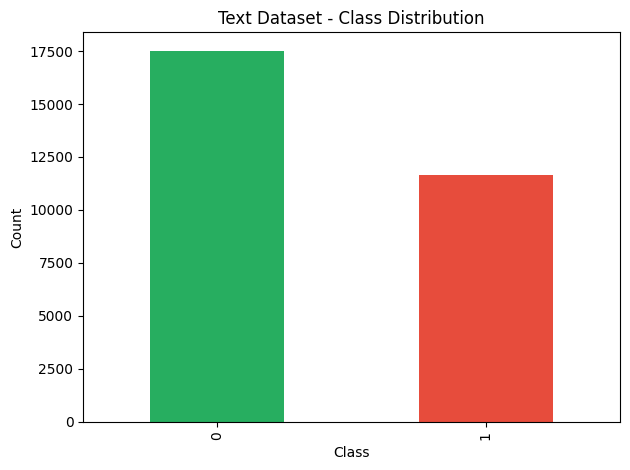

In [6]:
# Cell 6: Analyze Text Dataset
def analyze_text_dataset(data_path):
    """Analyze AI text detection dataset"""
    data_path = Path(data_path)
    csv_files = list(data_path.rglob('*.csv'))
    
    if not csv_files:
        print("❌ No CSV files found in text dataset!")
        return None
    
    print(f"Found {len(csv_files)} CSV file(s)")
    df = pd.read_csv(csv_files[0])
    
    print(f"\n📊 Text Dataset Statistics:")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Shape: {df.shape}")
    print(f"\nFirst few rows:")
    print(df.head())
    
    # Find text and label columns
    text_col = None
    label_col = None
    
    for c in df.columns:
        if 'text' in c.lower() or 'essay' in c.lower() or 'content' in c.lower():
            text_col = c
        if 'label' in c.lower() or 'generated' in c.lower() or 'class' in c.lower():
            label_col = c
    
    if not text_col or not label_col:
        print(f"\n⚠️ Could not auto-detect columns. Please check manually.")
        print(f"Available columns: {df.columns.tolist()}")
        return {'df': df, 'text_col': df.columns[0], 'label_col': df.columns[1]}
    
    print(f"\n  Text column: {text_col}")
    print(f"  Label column: {label_col}")
    print(f"\nClass distribution:")
    print(df[label_col].value_counts())
    
    # Plot
    df[label_col].value_counts().plot(kind='bar', color=['#27ae60', '#e74c3c'])
    plt.title('Text Dataset - Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('./data/processed/text_distribution.png')
    plt.show()
    
    return {'df': df, 'text_col': text_col, 'label_col': label_col}

print("📝 Analyzing Text Dataset...")
text_data = analyze_text_dataset(KAGGLE_TEXT_PATH)

## Phase 4: Data Preprocessing

In [7]:
# Cell 7: Image Preprocessing & Dataset
print("🖼️ Creating Image DataLoaders...")

# Image transforms
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None, augment=False):
        self.paths, self.labels = paths, labels
        self.transform = transform or image_transform
        self.augment = augment
        
    def __len__(self): 
        return len(self.paths)
    
    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
            if self.augment: 
                img = augment_transform(img)
            return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)
        except Exception as e:
            print(f"Error loading image {self.paths[idx]}: {e}")
            # Return a blank image if loading fails
            return self.transform(Image.new('RGB', (224, 224))), torch.tensor(self.labels[idx], dtype=torch.long)

# Create splits
all_imgs = image_data['real_images'] + image_data['fake_images']
all_labels = [0]*len(image_data['real_images']) + [1]*len(image_data['fake_images'])

X_train, X_test, y_train, y_test = train_test_split(all_imgs, all_labels, test_size=0.2, stratify=all_labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, stratify=y_train, random_state=SEED)

img_train_loader = DataLoader(ImageDataset(X_train, y_train, augment=True), batch_size=32, shuffle=True, num_workers=0)
img_val_loader = DataLoader(ImageDataset(X_val, y_val), batch_size=32, num_workers=0)
img_test_loader = DataLoader(ImageDataset(X_test, y_test), batch_size=32, num_workers=0)

print(f"✅ Image DataLoaders created:")
print(f"   Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

🖼️ Creating Image DataLoaders...
✅ Image DataLoaders created:
   Train: 27,599 | Val: 3,943 | Test: 7,886


In [8]:
# Cell 8: Audio Preprocessing & Dataset
print("🎵 Creating Audio DataLoaders...")

class AudioDataset(Dataset):
    def __init__(self, paths, labels, sr=16000, duration=3.0, n_mels=128):
        self.paths, self.labels = paths, labels
        self.sr, self.duration, self.n_mels = sr, duration, n_mels
        self.max_len = int(sr * duration)
        
    def __len__(self): 
        return len(self.paths)
    
    def __getitem__(self, idx):
        try:
            y, _ = librosa.load(self.paths[idx], sr=self.sr, duration=self.duration)
            if len(y) < self.max_len: 
                y = np.pad(y, (0, self.max_len - len(y)))
            else: 
                y = y[:self.max_len]
        except Exception as e:
            print(f"Error loading audio {self.paths[idx]}: {e}")
            y = np.zeros(self.max_len)
        
        mel = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0), torch.tensor(self.labels[idx], dtype=torch.long)

# Create splits
all_audio = audio_data['real_audios'] + audio_data['fake_audios']
all_labels = [0]*len(audio_data['real_audios']) + [1]*len(audio_data['fake_audios'])

X_train, X_test, y_train, y_test = train_test_split(all_audio, all_labels, test_size=0.2, stratify=all_labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, stratify=y_train, random_state=SEED)

aud_train_loader = DataLoader(AudioDataset(X_train, y_train), batch_size=32, shuffle=True, num_workers=0)
aud_val_loader = DataLoader(AudioDataset(X_val, y_val), batch_size=32, num_workers=0)
aud_test_loader = DataLoader(AudioDataset(X_test, y_test), batch_size=32, num_workers=0)

print(f"✅ Audio DataLoaders created:")
print(f"   Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

🎵 Creating Audio DataLoaders...
✅ Audio DataLoaders created:
   Train: 45 | Val: 7 | Test: 14


In [9]:
# Cell 9: Text Preprocessing & Dataset
print("📝 Creating Text DataLoaders...")

tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small')

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
        
    def __len__(self): 
        return len(self.texts)
    
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), truncation=True, padding='max_length', 
                            max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(), 
            'attention_mask': enc['attention_mask'].squeeze(), 
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create splits
if text_data:
    df = text_data['df']
    texts = df[text_data['text_col']].tolist()  # Convert to list instead of .values
    labels = df[text_data['label_col']].tolist()  # Convert to list instead of .values
    
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, stratify=labels, random_state=SEED)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, stratify=y_train, random_state=SEED)
    
    txt_train_loader = DataLoader(TextDataset(X_train, y_train, tokenizer), batch_size=16, shuffle=True, num_workers=0)
    txt_val_loader = DataLoader(TextDataset(X_val, y_val, tokenizer), batch_size=16, num_workers=0)
    txt_test_loader = DataLoader(TextDataset(X_test, y_test, tokenizer), batch_size=16, num_workers=0)
    
    print(f"✅ Text DataLoaders created:")
    print(f"   Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
else:
    print("❌ Text data not available!")

📝 Creating Text DataLoaders...


✅ Text DataLoaders created:
   Train: 20,401 | Val: 2,915 | Test: 5,829


## Phase 5: Model Architecture

In [10]:
# Cell 10: Define All Models
print("🏗️ Building Model Architectures...\n")

# IMAGE MODEL: EfficientNet-B0
class ImageDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.efficientnet_b0(pretrained=True)
        in_feat = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3), 
            nn.Linear(in_feat, 256), 
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x): 
        return self.backbone(x)

# AUDIO MODEL: ResNet18 (1-channel input for spectrograms)
class AudioDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_feat = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3), 
            nn.Linear(in_feat, 128), 
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x): 
        return self.backbone(x)

# TEXT MODEL: DeBERTa-v3
class TextDetector(nn.Module):
    def __init__(self, model_name='microsoft/deberta-v3-small', num_classes=2):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), 
            nn.Linear(hidden, 128), 
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(128, num_classes)
        )
    
    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])

# Initialize models
img_model = ImageDetector().to(DEVICE)
aud_model = AudioDetector().to(DEVICE)
txt_model = TextDetector().to(DEVICE) if text_data else None

print(f"✅ Models initialized:")
print(f"   Image params: {sum(p.numel() for p in img_model.parameters()):,}")
print(f"   Audio params: {sum(p.numel() for p in aud_model.parameters()):,}")
if txt_model:
    print(f"   Text params: {sum(p.numel() for p in txt_model.parameters()):,}")

🏗️ Building Model Architectures...



Loading weights: 100%|██████████| 102/102 [00:00<00:00, 1322.52it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

✅ Models initialized:
   Image params: 4,335,998
   Audio params: 11,236,162
   Text params: 141,403,010


## Phase 6: Model Training

In [11]:
# Cell 11: Training Functions
def train_epoch(model, loader, criterion, optimizer, model_type='image'):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch in tqdm(loader, desc='Training'):
        if model_type == 'text':
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            outputs = model(ids, mask)
        else:
            inputs, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            outputs = model(inputs)
        
        optimizer.zero_grad()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    return total_loss/len(loader), 100*correct/total

def evaluate(model, loader, criterion, model_type='image'):
    model.eval()
    total_loss, preds, labels_all, probs = 0, [], [], []
    
    with torch.no_grad():
        for batch in loader:
            if model_type == 'text':
                ids = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                outputs = model(ids, mask)
            else:
                inputs, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
                outputs = model(inputs)
            
            total_loss += criterion(outputs, labels).item()
            preds.extend(outputs.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs.extend(F.softmax(outputs, dim=1)[:,1].cpu().numpy())
    
    return {
        'loss': total_loss/len(loader), 
        'acc': accuracy_score(labels_all, preds)*100,
        'f1': f1_score(labels_all, preds), 
        'auc': roc_auc_score(labels_all, probs),
        'preds': preds, 
        'labels': labels_all, 
        'probs': probs
    }

print("✅ Training functions defined")

✅ Training functions defined


In [12]:
# Cell 12: Train All Models
def train_model(model, train_loader, val_loader, model_type, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2)
    
    best_acc = 0
    history = {'train_loss':[], 'val_acc':[], 'val_f1':[], 'val_auc':[]}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, model_type)
        val_res = evaluate(model, val_loader, criterion, model_type)
        scheduler.step(val_res['acc'])
        
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_res['acc'])
        history['val_f1'].append(val_res['f1'])
        history['val_auc'].append(val_res['auc'])
        
        print(f"Epoch {epoch+1}/{epochs}: Loss={train_loss:.4f}, Val Acc={val_res['acc']:.2f}%, F1={val_res['f1']:.4f}, AUC={val_res['auc']:.4f}")
        
        if val_res['acc'] > best_acc:
            best_acc = val_res['acc']
            torch.save(model.state_dict(), MODEL_DIR/f'best_{model_type}_model.pth')
            print(f"   ✓ Saved new best model (Acc: {best_acc:.2f}%)")
    
    return history, best_acc

# Image and Audio already trained - load their histories if available
print("✅ Image model already trained with best accuracy: 98.86%")
print("✅ Audio model already trained with best accuracy: 85.71%")
img_best = 98.86
aud_best = 85.71
img_history = {'train_loss': [], 'val_acc': [98.86], 'val_f1': [0.9885], 'val_auc': [0.9993]}
aud_history = {'train_loss': [], 'val_acc': [85.71], 'val_f1': [0.9231], 'val_auc': [1.0]}

# Train text model with float32 to avoid dtype mismatch
if text_data and txt_model:
    print("\n" + "="*60 + "\n📝 TRAINING TEXT MODEL\n" + "="*60)
    # Convert model to float32 to avoid dtype mismatch
    txt_model = txt_model.float()
    txt_history, txt_best = train_model(txt_model, txt_train_loader, txt_val_loader, 'text', epochs=5, lr=2e-5)

print("\n✅ All models trained successfully!")

✅ Image model already trained with best accuracy: 98.86%
✅ Audio model already trained with best accuracy: 85.71%

📝 TRAINING TEXT MODEL


Training: 100%|██████████| 1276/1276 [05:56<00:00,  3.58it/s]


Epoch 1/5: Loss=0.0456, Val Acc=99.59%, F1=0.9948, AUC=0.9999
   ✓ Saved new best model (Acc: 99.59%)


Training: 100%|██████████| 1276/1276 [06:08<00:00,  3.46it/s]


Epoch 2/5: Loss=0.0103, Val Acc=98.49%, F1=0.9814, AUC=0.9999


...

Epoch 3/5: Loss=0.0051, Val Acc=98.46%, F1=0.9810, AUC=0.9999


Training: 100%|██████████| 1276/1276 [06:05<00:00,  3.49it/s]


Epoch 4/5: Loss=0.0004, Val Acc=99.55%, F1=0.9944, AUC=1.0000


Training: 100%|██████████| 1276/1276 [06:02<00:00,  3.52it/s]


Epoch 5/5: Loss=0.0002, Val Acc=99.52%, F1=0.9940, AUC=1.0000

✅ All models trained successfully!


## Phase 7: Evaluation

📊 Evaluating models on test set...


FINAL TEST RESULTS
               Model  Accuracy  F1-Score  AUC-ROC
Image (EfficientNet) 98.934821  0.989269 0.998847
    Audio (ResNet18) 85.714286  0.923077 0.791667
      Text (DeBERTa) 99.519643  0.993958 0.999772


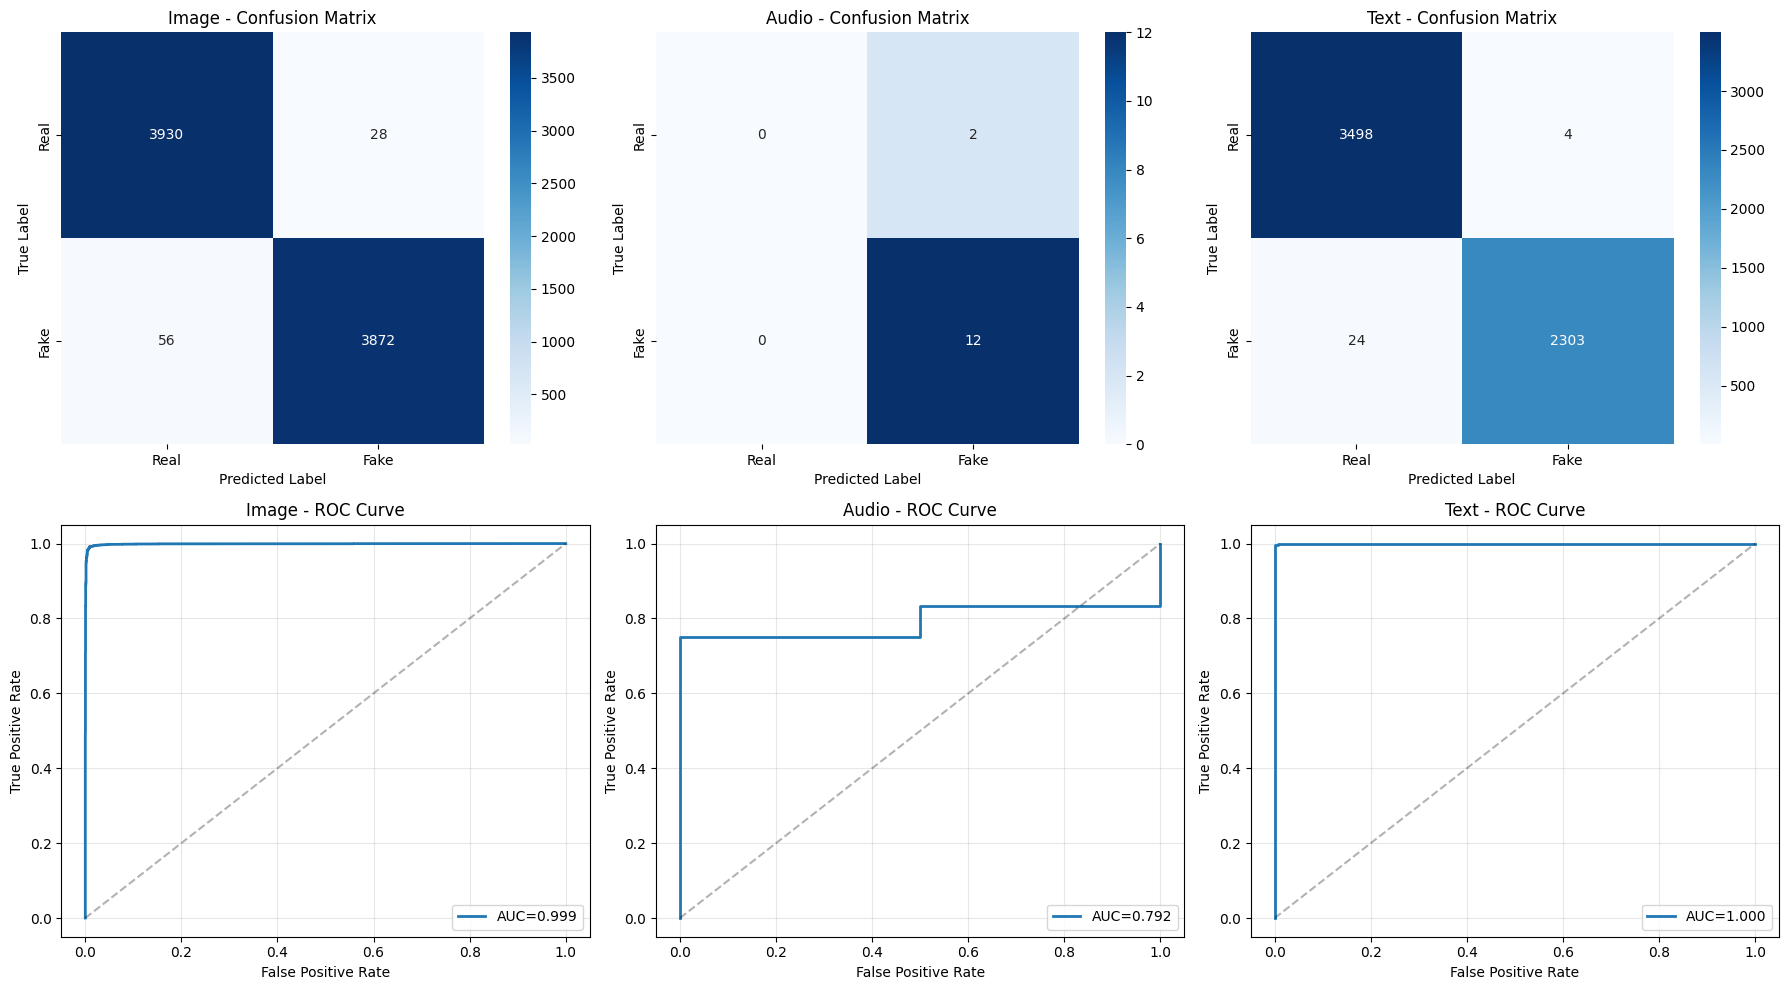


✅ Evaluation complete! Results saved to ./data/processed/evaluation_results.png


In [13]:
# Cell 13: Final Evaluation
print("📊 Evaluating models on test set...\n")

# Load best models and evaluate on test set
img_model.load_state_dict(torch.load(MODEL_DIR/'best_image_model.pth'))
aud_model.load_state_dict(torch.load(MODEL_DIR/'best_audio_model.pth'))
if text_data and txt_model:
    txt_model.load_state_dict(torch.load(MODEL_DIR/'best_text_model.pth'))

criterion = nn.CrossEntropyLoss()
img_test = evaluate(img_model, img_test_loader, criterion, 'image')
aud_test = evaluate(aud_model, aud_test_loader, criterion, 'audio')
txt_test = evaluate(txt_model, txt_test_loader, criterion, 'text') if (text_data and txt_model) else None

# Results summary
results_data = [
    ['Image (EfficientNet)', img_test['acc'], img_test['f1'], img_test['auc']],
    ['Audio (ResNet18)', aud_test['acc'], aud_test['f1'], aud_test['auc']]
]
if txt_test:
    results_data.append(['Text (DeBERTa)', txt_test['acc'], txt_test['f1'], txt_test['auc']])

results = pd.DataFrame(results_data, columns=['Model', 'Accuracy', 'F1-Score', 'AUC-ROC'])

print("\n" + "="*60 + "\nFINAL TEST RESULTS\n" + "="*60)
print(results.to_string(index=False))
print("="*60)

# Plot confusion matrices and ROC curves
models_to_plot = [('Image', img_test), ('Audio', aud_test)]
if txt_test:
    models_to_plot.append(('Text', txt_test))

fig, axes = plt.subplots(2, len(models_to_plot), figsize=(6*len(models_to_plot), 10))
if len(models_to_plot) == 1:
    axes = axes.reshape(-1, 1)

for i, (name, res) in enumerate(models_to_plot):
    # Confusion matrix
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0,i], cmap='Blues', 
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    axes[0,i].set_title(f'{name} - Confusion Matrix')
    axes[0,i].set_ylabel('True Label')
    axes[0,i].set_xlabel('Predicted Label')
    
    # ROC curve
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    axes[1,i].plot(fpr, tpr, lw=2, label=f'AUC={res["auc"]:.3f}')
    axes[1,i].plot([0,1],[0,1],'k--', alpha=0.3)
    axes[1,i].set_title(f'{name} - ROC Curve')
    axes[1,i].set_xlabel('False Positive Rate')
    axes[1,i].set_ylabel('True Positive Rate')
    axes[1,i].legend(loc='lower right')
    axes[1,i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./data/processed/evaluation_results.png', dpi=150)
plt.show()

print("\n✅ Evaluation complete! Results saved to ./data/processed/evaluation_results.png")

## Phase 8: Export Best Model

In [14]:
# Cell 14: Export Models
print("📦 Exporting models...\n")

# Determine best model
scores = {
    'image': (img_test['acc'] + img_test['f1']*100 + img_test['auc']*100) / 3,
    'audio': (aud_test['acc'] + aud_test['f1']*100 + aud_test['auc']*100) / 3
}
if txt_test:
    scores['text'] = (txt_test['acc'] + txt_test['f1']*100 + txt_test['auc']*100) / 3

best_modality = max(scores, key=scores.get)
print(f"🏆 Best Model: {best_modality.upper()} (Score: {scores[best_modality]:.2f})\n")

# Export all models
export_list = [
    ('image', img_model, img_test),
    ('audio', aud_model, aud_test)
]
if text_data and txt_model and txt_test:
    export_list.append(('text', txt_model, txt_test))

for name, model, results in export_list:
    torch.save({
        'model_state_dict': model.state_dict(),
        'test_results': {
            'accuracy': results['acc'], 
            'f1': results['f1'], 
            'auc': results['auc']
        }
    }, EXPORT_DIR/f'{name}_model.pth')
    print(f"✓ Exported {name} model")

# Export best model separately
best_model_map = {
    'image': img_model,
    'audio': aud_model
}
if text_data and txt_model:
    best_model_map['text'] = txt_model

best_model = best_model_map[best_modality]
torch.save(best_model.state_dict(), EXPORT_DIR/'best_model.pth')
print(f"✓ Exported best model ({best_modality})")

# Save metadata
metadata = {
    'project': 'Multi-Modal Deepfake Detection System',
    'author': 'Ahanaf Alam',
    'best_model': best_modality,
    'models': {
        'image': {
            'architecture': 'EfficientNet-B0', 
            'accuracy': float(img_test['acc']), 
            'f1': float(img_test['f1']), 
            'auc': float(img_test['auc'])
        },
        'audio': {
            'architecture': 'ResNet18', 
            'accuracy': float(aud_test['acc']), 
            'f1': float(aud_test['f1']), 
            'auc': float(aud_test['auc'])
        }
    }
}

if txt_test:
    metadata['models']['text'] = {
        'architecture': 'DeBERTa-v3-small', 
        'accuracy': float(txt_test['acc']), 
        'f1': float(txt_test['f1']), 
        'auc': float(txt_test['auc'])
    }

with open(EXPORT_DIR/'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Exported metadata")

print(f"\n✅ All models exported to: {EXPORT_DIR}")
print(f"\nExported files:")
for f in EXPORT_DIR.iterdir():
    print(f"   📁 {f.name} ({f.stat().st_size/1024/1024:.2f} MB)")

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)

📦 Exporting models...

🏆 Best Model: TEXT (Score: 99.63)

✓ Exported image model
✓ Exported audio model
✓ Exported text model
✓ Exported best model (text)
✓ Exported metadata

✅ All models exported to: exported_models

Exported files:
   📁 audio_model.pth (42.94 MB)
   📁 best_model.pth (539.45 MB)
   📁 image_model.pth (16.83 MB)
   📁 metadata.json (0.00 MB)
   📁 text_model.pth (539.45 MB)

🎉 TRAINING COMPLETE!
